In [9]:
import numpy as np
from numpy import round
import matplotlib.pyplot as plt
from tqdm import tqdm

In [10]:
def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def gamma2_k(_kx, _ky, eta = 1.):
    return 1/4 * (np.cos(_kx)**2 + np.cos(_ky)**2 + 2 * np.cos(_kx) * np.cos(_ky) * np.cos(np.pi/2 * (1 - eta)))

def a_func(t, n, delta = 1., lamb = 0., alpha = 1.):
    return 2 * (delta + t - 2 * n * (t/2 + alpha * lamb * delta))

def b_func(t, n, delta = 1., lamb = 0., beta = 1.):
    return 2 * (1 - 2 * n + n**2 + 3/4 * (t)**2 + beta * t * lamb * delta )

def get_bog_pars(t, n, _kx, _ky, delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1.):
    a = a_func(t, n, delta, lamb, alpha)
    b = b_func(t, n, delta, lamb, beta)

    wk = np.abs(np.sqrt(a**2 - b**2 * gamma2_k(_kx, _ky, eta) + 0j))
    
    return a, b, wk

def t_func(b, wk, gamma2k, N):
    return np.abs(b)/N * np.real(np.sum(np.divide(gamma2k, wk)))

def n_func(a, wk, N):
    return 1/(2*N) * np.sum(np.abs(np.divide(a, wk) - 1))

In [11]:
def SC_MF(delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1., n0 = 0., t0 = 0., leapfrog : bool = False, k_bins = 50, n_steps = 10, disable_tqdm = False):
    # strating parameters
    n_old = n0
    t_old = t0

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')

    t_array = []
    n_array = []

    CHI = .25

    for _ in tqdm(range(n_steps), disable = disable_tqdm):
        # get general parameters
        a, b, wk = get_bog_pars(t_old, n_old, px, py, delta, lamb, eta, alpha, beta)
        gamma2k = gamma2_k(px, py, eta)

        # get new t
        t_new = t_func(b, wk, gamma2k, N)

        # if leapfrog -> update t and delta_k
        if leapfrog:
            t_old = CHI * t_new + (1 - CHI) * t_old
            a, b, wk = get_bog_pars(t_old, n_old, px, py, delta, lamb, eta, alpha, beta)

        # get new n
        n_new = n_func(a, wk, N)

        if not leapfrog:
            t_old = CHI * t_new + (1 - CHI) * t_old
        n_old = CHI * n_new + (1 - CHI) * n_old

        t_array.append(t_old)
        n_array.append(n_old)
        
    return np.array(t_array), np.array(n_array), range(n_steps)

In [12]:
def disp(n, t, delta = 1., l = 0., eta = 1., _print = True, alpha = 1., beta = 1.):

    a = a_func(t, n, delta, l, alpha)
    b = b_func(t, n, delta, l, beta)

    #print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    const = 0.

    if b**2 > a**2:
        if _print:
            print('IMAGINARY')
        const = 0j

    k = np.linspace(-np.pi, np.pi, 100, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')

    disp = np.abs(np.sqrt(np.abs(a)**2 - np.abs(b)**2 * gamma2_k(px, py, eta) + const))
    
    gap_g = np.min(disp)
    gap_x = np.max(disp)

    if _print:
        print(f'Ak = {round(a, 5)}, Bk = {round(b, 5)}')
        print(f'Gap at min point: {round(gap_g, 3)}')
        print(f'Gap at max point: {round(gap_x, 3)}')

    return gap_g, gap_x

In [13]:
def get_mf(delta = 1., lamb = 0., eta = 1., alpha = 1., beta = 1., n0 = 1., t0 = 1., k_bins = 50, froggie = False, plot_changes : bool = False, n_steps = 20, _print = True):
    ts, ns, steps = SC_MF(delta, lamb, eta, alpha, beta, n0, t0, leapfrog=froggie, k_bins=k_bins, n_steps = n_steps, disable_tqdm = not _print)
    fin_t = ts[-1]
    fin_n = ns[-1]

    if _print:
        print(f'Final t = {round(fin_t, 5)}')
        print(f'Final n = {round(fin_n, 5)}')

    if plot_changes:
        plt.scatter(steps[1:], abs(ts[1:] - np.roll(ts[:-1], 1)), label = 't')
        plt.scatter(steps[1:], abs(ns[1:] - np.roll(ns[:-1], 1)), label = 'n')
        plt.yscale('log')
        plt.legend()
        plt.show()

    disp(fin_n, fin_t, delta, lamb, eta, _print = _print, alpha = alpha, beta = beta)

    return fin_t, fin_n

In [14]:
def plot_disp(delta, lamb, eta, n, t, alpha = 1., beta = 1.):
    k = np.linspace(0, np.pi, 100, endpoint = False)

    kx = np.append(k, np.append([np.pi]*len(k), np.flip(k)))
    ky = np.append([0]*len(k), np.append(k, np.flip(k)))

    steps = range(len(kx))

    a = a_func(t, n, delta, lamb, alpha)
    b = b_func(t, n, delta, lamb, beta)

    disp = np.abs(np.sqrt(np.abs(a)**2 - np.abs(b)**2 * gamma2_k(kx, ky, eta) + 0j))
    plt.plot(steps, disp)
    plt.show()


100%|██████████| 20/20 [00:00<00:00, 40.04it/s]

Final t = 0.23705
Final n = 0.05247
Ak = 2.44922, Bk = 1.87993
Gap at min point: 1.57
Gap at max point: 2.449


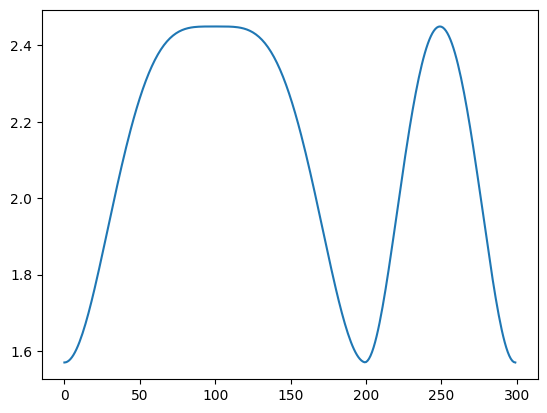

100%|██████████| 100/100 [00:02<00:00, 38.56it/s]

Final t = 0.2731
Final n = 0.06455
Ak = 2.25276, Bk = 1.86202
Gap at min point: 1.268
Gap at max point: 2.253


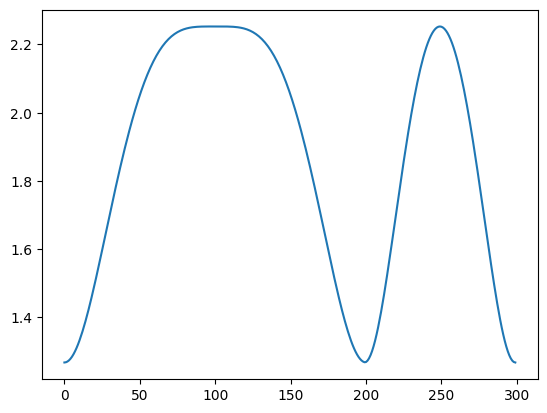

100%|██████████| 100/100 [00:02<00:00, 38.79it/s]

Final t = 0.68904
Final n = 0.26607
IMAGINARY
Ak = 1.94713, Bk = 3.16757
Gap at min point: 0.098
Gap at max point: 2.498


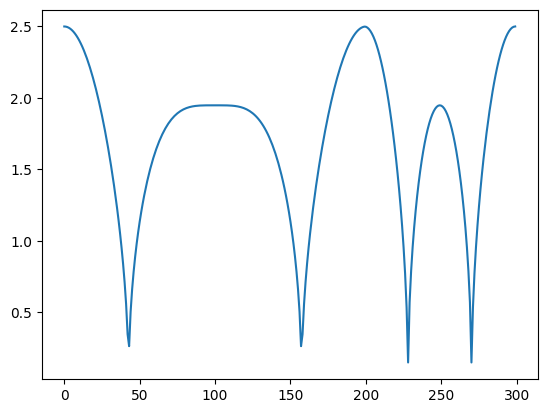

In [15]:
_t, _n = get_mf(1., 0., 1., k_bins = 1000, n_steps = 20)
plot_disp(1., 0., 1., _n, _t)

alpha = 1.
beta = 0.

_t, _n = get_mf(1., 1., 1., alpha, beta, .2, .2, k_bins = 1000, n_steps = 100, plot_changes=False)
plot_disp(1., 1., 1., _n, _t, alpha, beta)

beta = 1.

_t, _n = get_mf(1., 1., 1., alpha, beta, .2, .2, k_bins = 1000, n_steps = 100, plot_changes=False)
plot_disp(1., 1., 1., _n, _t, alpha, beta)

100%|██████████| 20/20 [00:00<00:00, 39.44it/s]

Final t = 0.12228
Final n = 0.01703
Ak = 4.24039, Bk = 1.95489
Gap at min point: 3.763
Gap at max point: 4.24


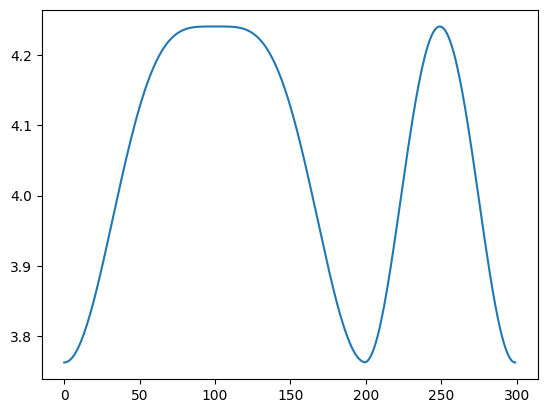

100%|██████████| 50/50 [00:08<00:00,  6.06it/s]

Final t = 0.12751
Final n = 0.0157
Ak = 4.12545, Bk = 1.9621
Gap at min point: 3.629
Gap at max point: 4.125


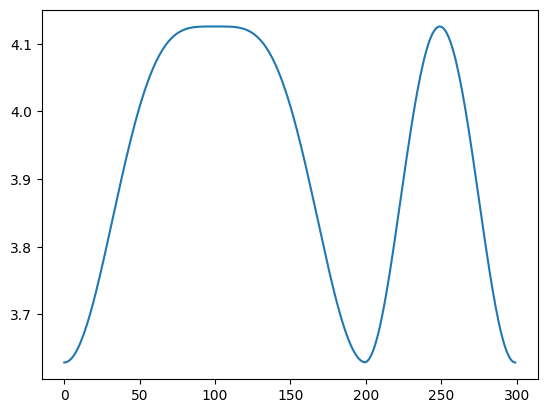

In [16]:
_t, _n = get_mf(2., 0., 1., k_bins = 1000, n_steps = 20)
plot_disp(2., 0., 1., _n, _t)

_t, _n = get_mf(2., 1., 1., 1., 0., .28, .72, k_bins = 2500, n_steps = 50, plot_changes=False)
plot_disp(2., 1., 1., _n, _t, 1., 0.)

100%|██████████| 50/50 [00:01<00:00, 38.19it/s]


Final t = 0.23833
Final n = 0.05321


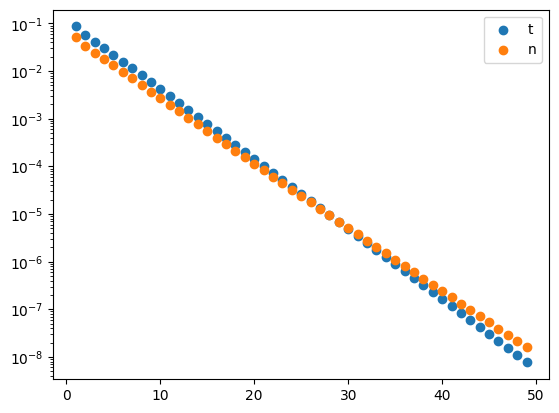

Ak = 2.23848, Bk = 1.87804
Gap at min point: 1.802
Gap at max point: 2.238


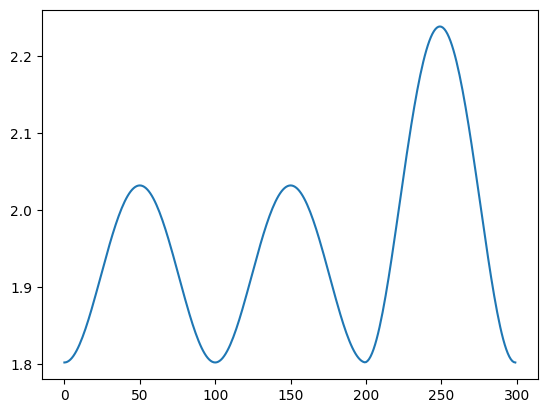

In [17]:
_t, _n = get_mf(1., 1., 0., 1., 0., n0 = .15, t0 = .4, k_bins = 1000, n_steps = 50, plot_changes = True)
plot_disp(1., 1., 0., _n, _t, 1., 0.)